In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from numpy.linalg import norm

#all-MiniLM-l6-v2 modeli kullanıldı. Bu model ürünlerin title ve decription bölümlerini 
#384 boyutlu vektörlere dönüştürür.
model = SentenceTransformer("all-MiniLM-L6-v2")


#Test ürünleri
products = [
    {
        "title": "Red Running Shoes",
        "description": "Comfortable red running shoes for daily jogging",
    },
    {
        "title": "Blue Denim Jacket",
        "description": "Stylish blue denim jacket for casual wear",
    },
    {
        "title": "Gaming Laptop",
        "description": "High performance laptop for gaming and development",
    }
]



#Vector DB (List)
vector_db = []

for product in products:

    text = product["title"] + " " + product["description"]

    embedding = model.encode(text)

    vector_db.append({
        "product": product,
        "vector": embedding
    })


# Cosine Similarity. İsteğe bağlı olarak Euclidean Distance, Manhattan Distence gibi yöntemlerde kullanılabilir.

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))


# Semantic Retrieval dediğimiz arama kısmı.
def search(query):

    query_vector = model.encode(query)

    scores = []

    for item in vector_db:
        sim = cosine_similarity(query_vector, item["vector"])
        scores.append((sim, item["product"]))

    scores.sort(reverse=True)

    return scores[:2]


# Fake LLM, vector search ile getirdiğimiz vectorleri Fake bir LLM içine koyarak kullanıcıya sunarız. (RAG'in son aşaması bu)
def llm_generate(query, retrieved_products):

    context = "\n".join(
        [p["title"] + ": " + p["description"] for _, p in retrieved_products]
    )

    answer = f"""
User Query: {query}

Relevant Products:
{context}

Suggested Product: {retrieved_products[0][1]['title']}
"""

    return answer


# Örnek RAG Kullanımı
query = input("Search: ")

retrieved = search(query)

response = llm_generate(query, retrieved)

print(response)

Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 2179.98it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Search:  I am a old guy. I am always cold.



User Query: I am a old guy. I am always cold.

Relevant Products:
Blue Denim Jacket: Stylish blue denim jacket for casual wear
Red Running Shoes: Comfortable red running shoes for daily jogging

Suggested Product: Blue Denim Jacket



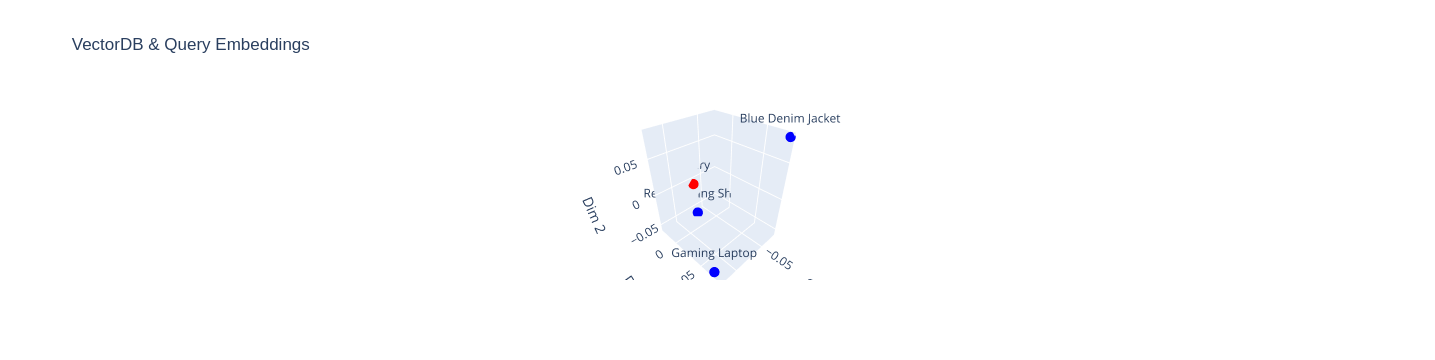

In [2]:
import plotly.graph_objects as go
import plotly.offline
import numpy as np

# Ürün ve query vektörleri
product_vectors = np.array([item["vector"] for item in vector_db])
query_vector = model.encode(query)

words = np.vstack([product_vectors, query_vector])
labels = [item["product"]["title"] for item in vector_db] + ["Query"]
colors = ["blue"]*len(vector_db) + ["red"]

sentences_data = [
    {
        "words": words,
        "labels": labels,
        "color": colors
    }
]

# Plot
def plot_dots(sentences_data, title, dims=[0, 1, 2]):
    data = [
        go.Scatter3d(
            x=sentence_data["words"][:, dims[0]],
            y=sentence_data["words"][:, dims[1]],
            z=sentence_data["words"][:, dims[2]],
            mode="markers+text",
            marker=dict(size=6, color=sentence_data["color"]),
            text=sentence_data["labels"],
            hoverinfo="text",
        ) for sentence_data in sentences_data
    ]

    layout = go.Layout(
        scene=dict(
            xaxis_title="Dim 0",
            yaxis_title="Dim 1",
            zaxis_title="Dim 2",
        ),
        title=title,
    )

    fig = go.Figure(data=data, layout=layout)
    plotly.offline.iplot(fig)  # notebook’da çalışır, HTML açma gerek yok

# RUN etme kısmı
plot_dots(sentences_data, "VectorDB & Query Embeddings")